In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

In [ ]:
L1_1_df = pd.read_pickle("./LVISF_SERC/LVISF1B_1_waveform_df")
L2_1_df = pd.read_pickle("./LVISF_SERC/LVISF2_1_RH_df")

L1_2_df = pd.read_pickle("./LVISF_SERC/LVISF1B_2_waveform_df")
L2_2_df = pd.read_pickle("./LVISF_SERC/LVISF2_2_RH_df")

# Add ellipsoid to geoid offset to Z0 and Z1215
L1_1_df['Z0'], L1_1_df['Z1215'] = L1_1_df['Z0'] + 34.613, L1_1_df['Z1215'] + 34.613
L1_2_df['Z0'], L1_2_df['Z1215'] = L1_2_df['Z0'] + 34.613, L1_2_df['Z1215'] + 34.613

In [11]:
L2_df = pd.concat([L2_1_df, L2_2_df], ignore_index=True)
L2_df

,LFID,SHOTNUMBER,X,Y,ZG,ZH,ZT,RH10,RH15,RH20,...,RH85,RH90,RH95,RH96,RH97,RH98,RH99,RH100,Sensitivity,Complexity
0,1.959432e+09,98011926.0,367995.544189,4.309984e+06,0.473,0.473,2.083,-1.05,-0.75,-0.75,...,0.30,0.30,0.45,0.45,0.60,0.60,0.75,1.61,0.954,0.145
1,1.959432e+09,98011927.0,367990.685222,4.309974e+06,0.513,0.513,2.163,-1.05,-0.90,-0.75,...,0.15,0.30,0.45,0.45,0.60,0.60,0.75,1.64,0.959,0.088
2,1.959432e+09,98011929.0,367984.531954,4.309989e+06,0.483,0.483,2.133,-1.01,-0.86,-0.71,...,0.19,0.34,0.49,0.49,0.64,0.64,0.64,1.64,0.969,0.088
3,1.959432e+09,98011930.0,367979.671120,4.309979e+06,0.543,0.543,2.183,-1.08,-0.79,-0.64,...,0.26,0.26,0.41,0.56,0.56,0.56,0.71,1.64,0.958,0.116
4,1.959432e+09,98011932.0,367973.604562,4.309995e+06,0.513,0.513,2.123,-1.01,-0.86,-0.71,...,0.19,0.34,0.49,0.49,0.49,0.64,0.79,1.61,0.975,0.116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207331,1.959432e+09,98241599.0,361620.476290,4.300682e+06,47.503,47.503,49.373,-1.16,-0.86,-0.71,...,0.19,0.34,0.49,0.49,0.63,0.63,0.78,1.87,0.985,0.131
207332,1.959432e+09,98241600.0,361615.603683,4.300671e+06,47.143,47.143,49.163,-1.23,-0.93,-0.78,...,0.26,0.41,0.56,0.56,0.56,0.71,0.86,2.02,0.987,0.116
207333,1.959432e+09,98241602.0,361631.415147,4.300677e+06,46.993,46.993,48.893,-1.16,-1.01,-0.86,...,0.34,0.34,0.49,0.63,0.63,0.63,0.78,1.90,0.989,0.089
207334,1.959432e+09,98241605.0,361642.265292,4.300672e+06,46.043,46.043,47.903,-1.01,-0.86,-0.71,...,0.19,0.34,0.49,0.49,0.63,0.63,0.78,1.87,0.987,0.076


In [ ]:
L1_df = pd.concat([L1_1_df, L1_2_df], ignore_index=True)
L1_df

,LFID,SHOTNUMBER,Z0,Z1215,Bin_distance,Mean_noise,TX_waveform,RX_waveform
0,1959431818,98011926,106.264565,-75.403915,0.149896,147.124023,"[145, 148, 153, 150, 141, 151, 147, 146, 148, ...","[142, 147, 149, 153, 149, 146, 151, 150, 149, ..."
1,1959431818,98011927,106.749420,-74.915291,0.149896,146.067825,"[152, 148, 140, 142, 140, 145, 145, 146, 148, ...","[143, 146, 149, 142, 143, 150, 148, 146, 149, ..."
2,1959431818,98011929,106.471107,-75.208710,0.149896,147.248062,"[152, 152, 147, 144, 150, 154, 150, 150, 149, ...","[147, 148, 146, 151, 149, 137, 140, 148, 141, ..."
3,1959431818,98011930,106.892578,-74.783463,0.149896,146.396317,"[149, 140, 150, 151, 147, 152, 148, 147, 148, ...","[148, 152, 149, 150, 146, 145, 145, 146, 142, ..."
4,1959431818,98011932,106.652672,-75.038261,0.149896,146.437988,"[150, 147, 150, 155, 153, 153, 151, 148, 150, ...","[152, 149, 148, 150, 149, 144, 145, 142, 141, ..."
...,...,...,...,...,...,...,...,...
207331,1959431819,98241599,152.850220,-28.582516,0.149896,145.677322,"[148, 150, 143, 143, 149, 148, 151, 159, 159, ...","[143, 145, 149, 155, 154, 156, 149, 148, 147, ..."
207332,1959431819,98241600,152.113251,-29.315783,0.149896,145.980621,"[149, 154, 156, 150, 147, 145, 144, 146, 149, ...","[139, 146, 141, 145, 146, 147, 153, 160, 146, ..."
207333,1959431819,98241602,152.645554,-28.801332,0.149896,145.916672,"[146, 155, 156, 158, 155, 148, 146, 151, 148, ...","[151, 146, 144, 152, 148, 145, 141, 137, 137, ..."
207334,1959431819,98241605,151.404572,-30.056299,0.149896,145.674423,"[152, 150, 150, 158, 150, 149, 153, 150, 150, ...","[148, 157, 147, 148, 148, 150, 152, 147, 145, ..."


In [ ]:
def denoise_clip_waveform(L1_df, L2_df, ind, width=1.3, n_thres=4):
    shotnum = L1_df.iloc[ind]['SHOTNUMBER'] 
    rx_wf = L1_df.iloc[ind]['RX_waveform']
    mean_noise = L1_df.iloc[ind]['Mean_noise']
    z0 = L1_df.iloc[ind]['Z0']
    zt_m, zg_m, zh_m = L2_df.iloc[ind]['ZT'], L2_df.iloc[ind]['ZG'], L2_df.iloc[ind]['ZH']
    x, y = L2_df.iloc[ind]['X'], L2_df.iloc[ind]['Y']
    zt, zg, zh = (z0 - zt_m)/0.15, (z0 - zg_m)/0.15, (z0 - zh_m)/0.15 # convert to bins

    # Apply a 1D Gaussian filter with sigma width
    rx_wf_sm = gaussian_filter1d(rx_wf, sigma=width)
    # Back threshold
    sig = np.std(rx_wf_sm[:int(zt)])
    thres = mean_noise + n_thres*sig
    if ind < 5:
        print(ind)
        plt.figure(figsize=(10, 4))
        plt.plot(rx_wf_sm, label='Smoothed RX_waveform')
        plt.axhline(y=mean_noise, color='y', linestyle='--', label='Mean noise')
        plt.axhline(y=thres, color='r', linestyle='--', label='Threshold')
        plt.axvline(x=zg, color='g', linestyle='--', label='ZG')
        plt.xlabel('Bin')
        plt.ylabel('Counts')
        plt.legend()
        plt.title(f'Shotnumber: {shotnum}')
        plt.show()
    amp_thres = mean_noise + 8*sig
    inds = np.where(rx_wf_sm[int(zg):] < thres)[0] 
    sig_end = inds[0] + int(zg)
    sig_end_m = zg_m - (sig_end - zg)*0.15 # convert to meters

    # Find peaks in the filtered waveform
    peaks, _ = find_peaks(rx_wf_sm[int(zt): sig_end+1])
    peaks  = peaks + int(zt) # add the offset

    # Clip the waveform to signal portion
    counts = rx_wf_sm[int(zt):sig_end+1]
    bins = np.arange(int(zt), sig_end+1)
    clipped_wf = np.column_stack((bins, counts))
    if ind < 5:
        plt.figure(figsize=(10, 4))
        plt.plot(clipped_wf[:, 0], clipped_wf[:, 1], label='Clipped RX_waveform')
        plt.xlabel('Bin')
        plt.ylabel('Counts')
        plt.legend()
        plt.title(f'Shotnumber: {shotnum}')
        plt.show()

    return (shotnum, clipped_wf, peaks, amp_thres, zt_m, zg_m, zh_m, sig_end_m, zt, zg, zh, sig_end)

Extract clipped waveform if maximum amplitude is above threshold:

  0%|          | 0/207336 [00:00<?, ?it/s]

0


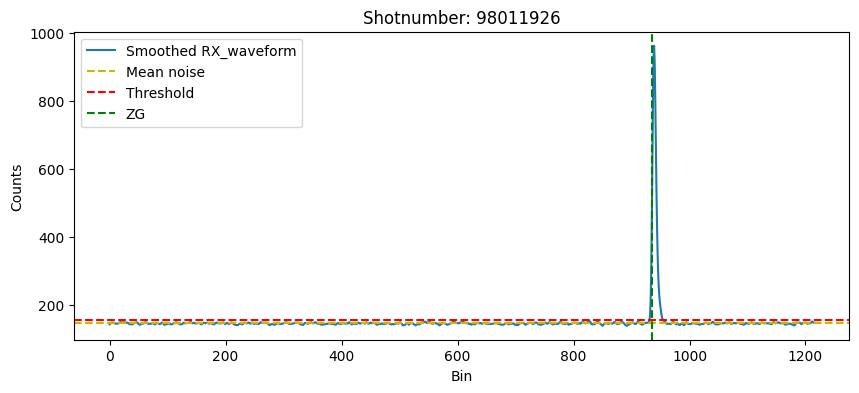

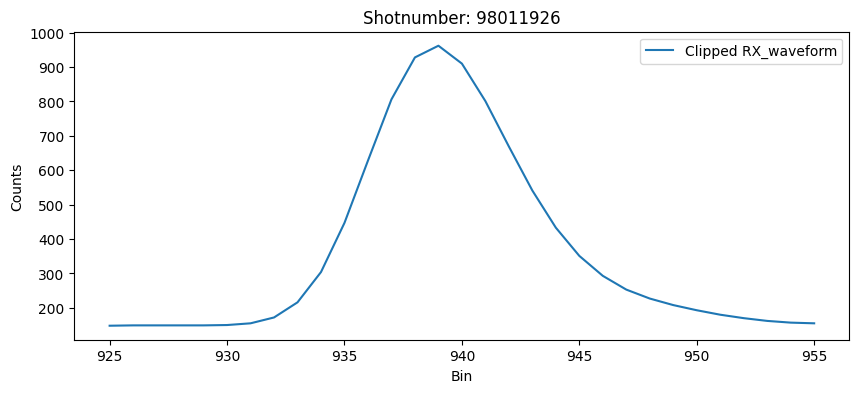

  0%|          | 1/207336 [00:00<11:35:08,  4.97it/s]

1


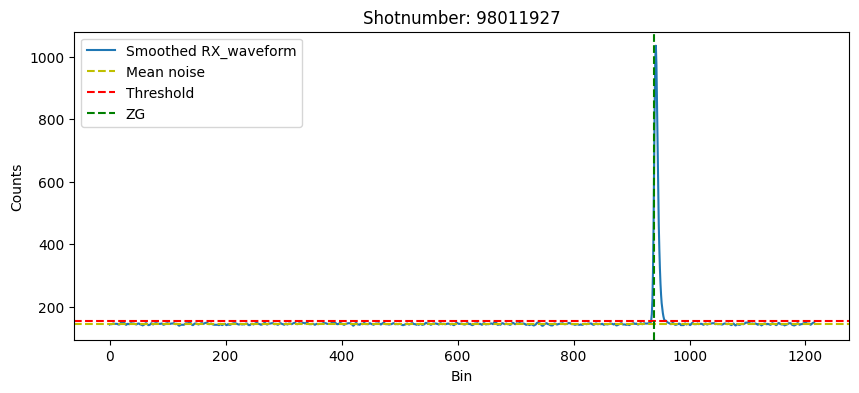

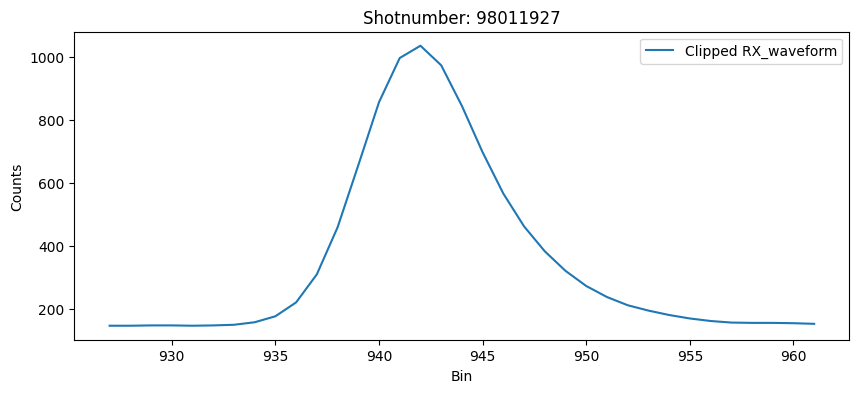

  0%|          | 2/207336 [00:00<9:29:22,  6.07it/s] 

2


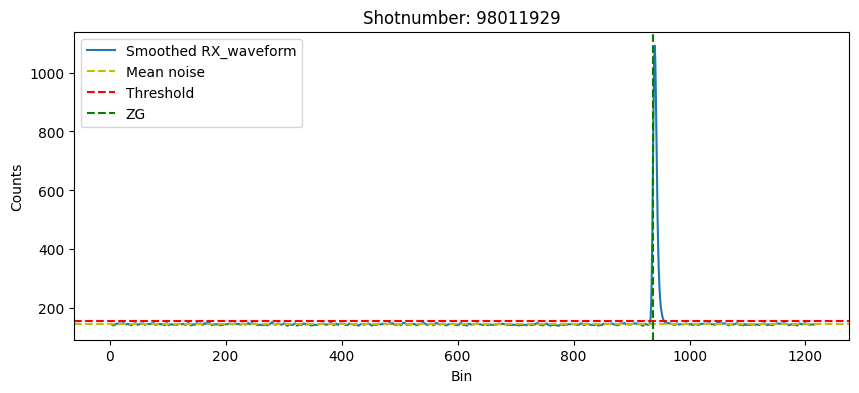

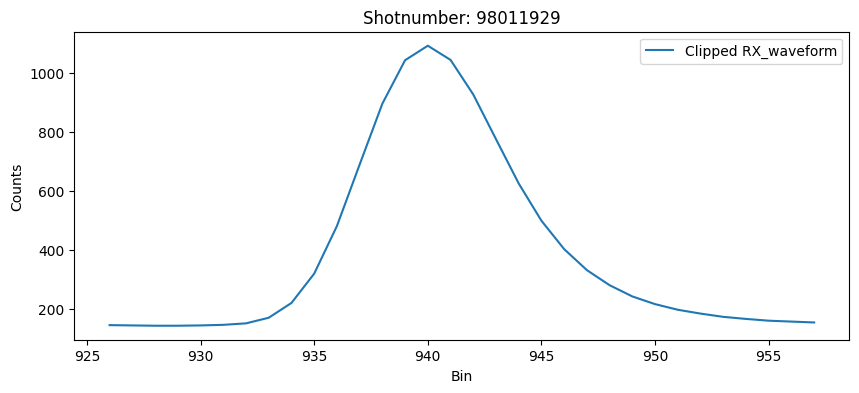

  0%|          | 3/207336 [00:00<9:04:37,  6.34it/s]

3


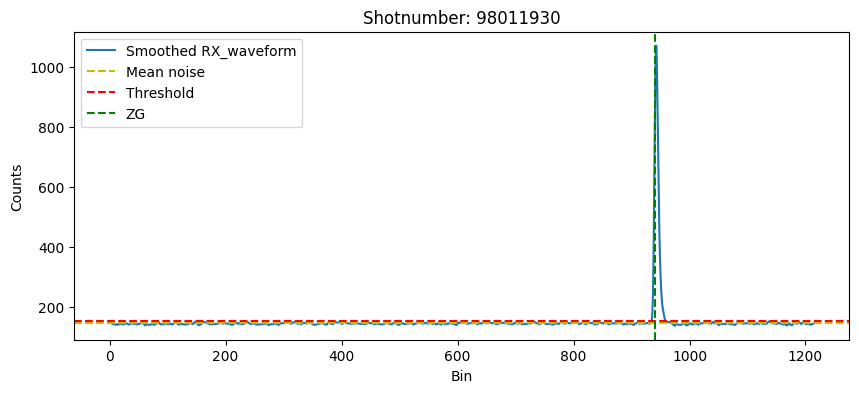

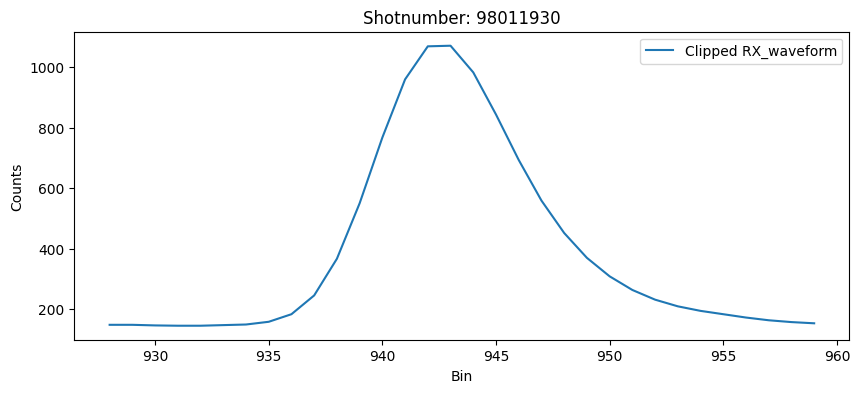

  0%|          | 4/207336 [00:00<8:34:22,  6.72it/s]

4


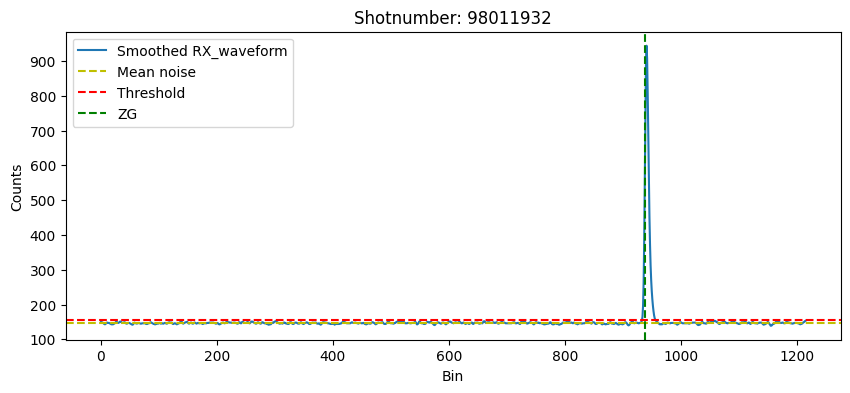

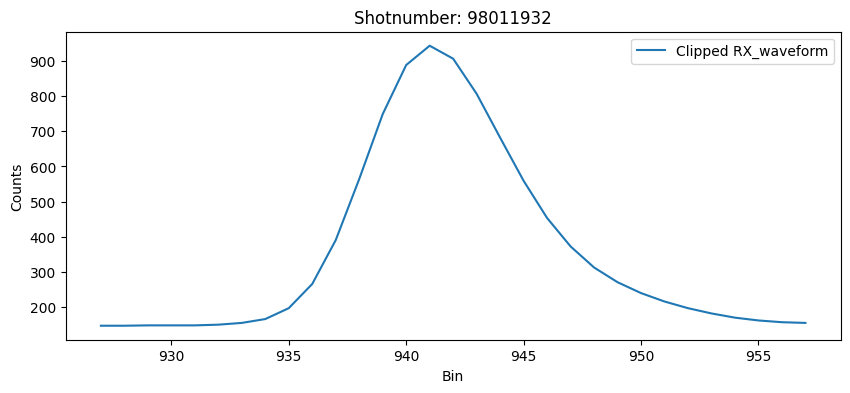

100%|██████████| 207336/207336 [58:08<00:00, 59.44it/s]


,Shotnumber,RX_waveform_clipped,Peaks,ZT_m,ZH_m,ZG_m,Signal_End_m,ZT,ZH,ZG,Signal_End
0,98011926,"[[925, 148], [926, 149], [927, 149], [928, 149...",939,2.083,0.473,0.473,-2.372437,925.29709,936.030423,936.030423,955
1,98011927,"[[927, 147], [928, 147], [929, 148], [930, 148...","[929, 942]",2.163,0.513,0.513,-2.787573,927.996178,938.996178,938.996178,961
2,98011929,"[[926, 146], [927, 145], [928, 144], [929, 144...",940,2.133,0.483,0.483,-2.465894,926.34071,937.34071,937.34071,957
3,98011930,"[[928, 149], [929, 149], [930, 147], [931, 146...",943,2.183,0.543,0.543,-2.344415,928.817231,939.750565,939.750565,959
4,98011932,"[[927, 146], [928, 146], [929, 147], [930, 147...",941,2.123,0.513,0.513,-2.284329,927.617805,938.351139,938.351139,957
...,...,...,...,...,...,...,...,...,...,...,...
207331,98241599,"[[920, 149], [921, 149], [922, 148], [923, 147...","[937, 964]",49.373,47.503,47.503,42.113226,920.601509,933.068175,933.068175,969
207332,98241600,"[[917, 157], [918, 162], [919, 165], [920, 164...","[919, 935, 966, 978]",49.163,47.143,47.143,39.426257,917.088382,930.555049,930.555049,982
207333,98241602,"[[922, 146], [923, 143], [924, 141], [925, 142...",939,48.893,46.993,46.993,42.808545,922.436966,935.103633,935.103633,963
207334,98241605,"[[920, 147], [921, 149], [922, 150], [923, 150...",937,47.903,46.043,46.043,42.467578,920.763854,933.163854,933.163854,957


In [ ]:
# Create a new DataFrame to store the clipped waveforms and their elevations 
clipped_wf_df = pd.DataFrame(columns=[
    'Shotnumber', 'RX_waveform_clipped', 'Peaks', 'ZT_m', 'ZH_m', 'ZG_m', 'Signal_End_m', 
    'ZT', 'ZH', 'ZG', 'Signal_End'])

# Apply the function to each row and append the results to the new DataFrame
for i in tqdm(range(len(L1_df))):
    shotnum, clipped_wf, peaks, ampthr, ztm, zgm, zhm, sig_endm, zt, zg, zh, sig_end = denoise_clip_waveform(L1_df, L2_df, i)
    counts = clipped_wf[:, 1]
    can_peaks = (peaks < int(zg)).sum() > 1 # check if there are more than one peak above ground
    max_valid, non_valid = counts.max() > ampthr, []

    #if can_peaks and max_valid: # append only if there are more than one peak above ground and the max value is above the threshold
    if max_valid: # append only if the max value is above the threshold
        clipped_wf_df.at[i, 'Shotnumber'] = shotnum
        clipped_wf_df.at[i, 'RX_waveform_clipped'] = clipped_wf
        clipped_wf_df.at[i, 'Peaks'] = peaks
        clipped_wf_df.at[i, 'ZT_m'], clipped_wf_df.at[i, 'ZT'] = ztm, zt
        clipped_wf_df.at[i, 'ZH_m'], clipped_wf_df.at[i, 'ZH'] = zhm, zh
        clipped_wf_df.at[i, 'ZG_m'], clipped_wf_df.at[i, 'ZG'] = zgm, zg
        clipped_wf_df.at[i, 'Signal_End_m'], clipped_wf_df.at[i, 'Signal_End'] = sig_endm, sig_end
    else:
        non_valid.append(i)

clipped_wf_df.to_pickle("clipped_wf_can_df")
clipped_wf_df